In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/prob_contact_raw.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/prob_contact_raw.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/prob_contact_raw.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/prob_contact_raw.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/prob_contact_raw.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/prob_contact_raw.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

gh_order = ['GH Fed-Fed', 'GH Fed-Starved', 'GH Starved-Starved']
si_order = ['SI Fed-Fed', 'SI Fed-Starved', 'SI Starved-Starved']

palette_gh = {
    'GH Fed-Fed': '#4C72B0',
    'GH Fed-Starved': '#55A868',
    'GH Starved-Starved': '#C44E52',
}

palette_si = {
    'SI Fed-Fed': '#4C72B0',
    'SI Fed-Starved': '#55A868',
    'SI Starved-Starved': '#C44E52',
}

if 'contact_during_episode' not in df.columns:
    df['contact_during_episode'] = df['contact_within_window']

df['contact_during_episode'] = df['contact_during_episode'].astype(bool)

if 'distance_bin' not in df.columns:
    distance_edges = np.arange(0, 11, 1)
    distance_labels = [f'{distance_edges[i]:g}-{distance_edges[i + 1]:g}' for i in range(len(distance_edges) - 1)]
    df['distance_bin'] = pd.cut(df['head_distance'], bins=distance_edges, labels=distance_labels, include_lowest=True)

if 'angle_bin' not in df.columns:
    angle_edges = np.arange(0, 181, 30)
    angle_labels = [f'{angle_edges[i]:g}-{angle_edges[i + 1]:g}' for i in range(len(angle_edges) - 1)]
    df['angle_bin'] = pd.cut(df['approach_angle'], bins=angle_edges, labels=angle_labels, include_lowest=True)

df['distance_bin'] = df['distance_bin'].astype(str)
df['angle_bin'] = df['angle_bin'].astype(str)

distance_order = sorted(df.loc[df['distance_bin'] != 'nan', 'distance_bin'].unique(), key=lambda x: float(x.split('-')[0]))
angle_order = sorted(df.loc[df['angle_bin'] != 'nan', 'angle_bin'].unique(), key=lambda x: float(x.split('-')[0]))
node_order = ['head', 'body', 'tail']

df['distance_center'] = df['distance_bin'].map({x: np.mean([float(v) for v in x.split('-')]) for x in distance_order})
df['angle_center'] = df['angle_bin'].map({x: np.mean([float(v) for v in x.split('-')]) for x in angle_order})

gh = df[df['Condition'].str.contains('GH')].copy()
si = df[df['Condition'].str.contains('SI')].copy()


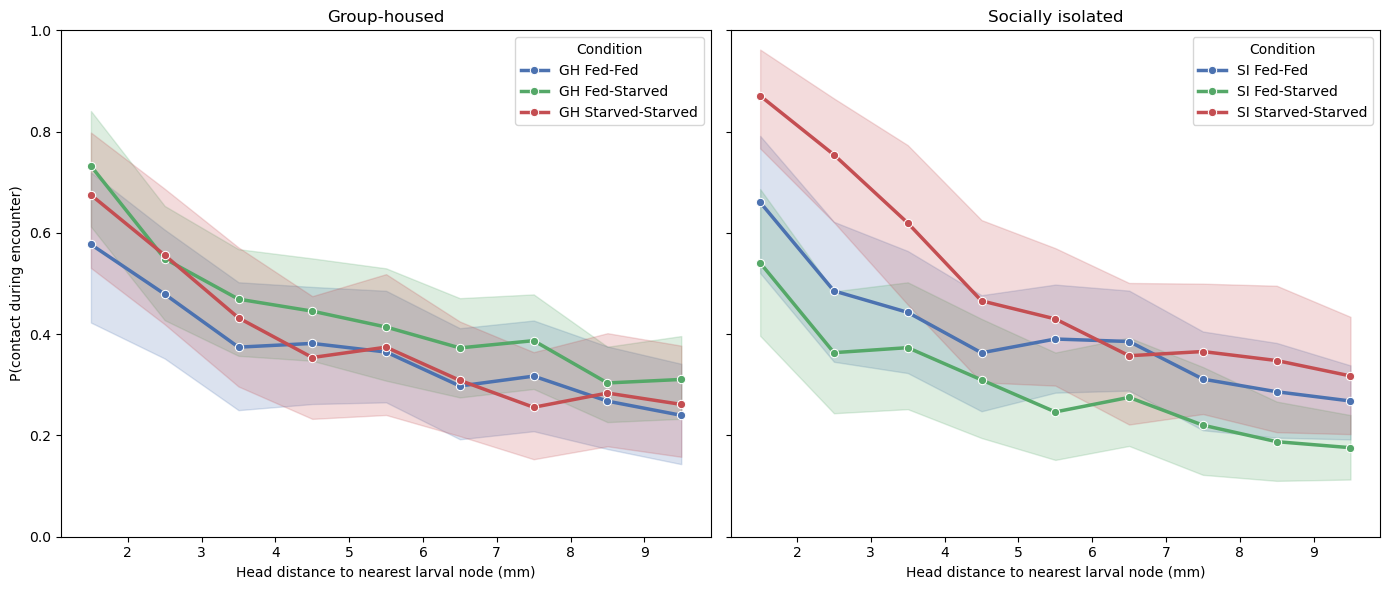

In [16]:
# Probability of future contact by current head distance, grouped by file
prob_by_distance = (
    df.dropna(subset=['distance_center'])
      .groupby(['Condition', 'file', 'distance_bin', 'distance_center'], observed=True, as_index=False)
      .agg(
          n_observations=('contact_during_episode', 'size'),
          n_contacts=('contact_during_episode', 'sum')
      )
)
prob_by_distance['prob_contact'] = prob_by_distance['n_contacts'] / prob_by_distance['n_observations']

gh_distance = prob_by_distance[prob_by_distance['Condition'].str.contains('GH')].copy()
si_distance = prob_by_distance[prob_by_distance['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------

sns.lineplot(
    data=gh_distance,
    x='distance_center',
    y='prob_contact',
    hue='Condition',
    hue_order=gh_order,
    palette=palette_gh,
    estimator='mean',
    errorbar=('ci', 95),
    marker='o',
    linewidth=2.5,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Head distance to nearest larval node (mm)')
axes[0].set_ylabel('P(contact during encounter)')
axes[0].set_ylim(0, 1)

# ---------------- SI ----------------

sns.lineplot(
    data=si_distance,
    x='distance_center',
    y='prob_contact',
    hue='Condition',
    hue_order=si_order,
    palette=palette_si,
    estimator='mean',
    errorbar=('ci', 95),
    marker='o',
    linewidth=2.5,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Head distance to nearest larval node (mm)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


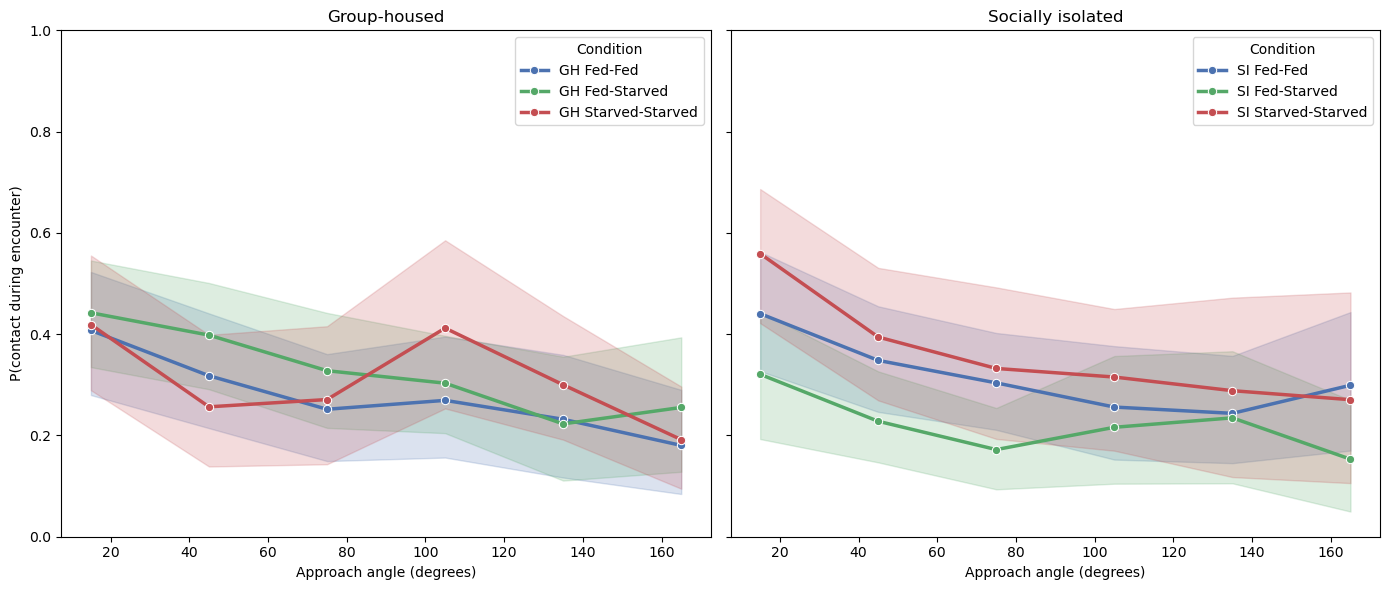

In [17]:
# Probability of future contact by approach angle, grouped by file
prob_by_angle = (
    df.dropna(subset=['angle_center'])
      .groupby(['Condition', 'file', 'angle_bin', 'angle_center'], observed=True, as_index=False)
      .agg(
          n_observations=('contact_during_episode', 'size'),
          n_contacts=('contact_during_episode', 'sum')
      )
)
prob_by_angle['prob_contact'] = prob_by_angle['n_contacts'] / prob_by_angle['n_observations']

gh_angle = prob_by_angle[prob_by_angle['Condition'].str.contains('GH')].copy()
si_angle = prob_by_angle[prob_by_angle['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.lineplot(
    data=gh_angle,
    x='angle_center',
    y='prob_contact',
    hue='Condition',
    hue_order=gh_order,
    palette=palette_gh,
    estimator='mean',
    errorbar=('ci', 95),
    marker='o',
    linewidth=2.5,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Approach angle (degrees)')
axes[0].set_ylabel('P(contact during encounter)')
axes[0].set_ylim(0, 1)

# ---------------- SI ----------------
sns.lineplot(
    data=si_angle,
    x='angle_center',
    y='prob_contact',
    hue='Condition',
    hue_order=si_order,
    palette=palette_si,
    estimator='mean',
    errorbar=('ci', 95),
    marker='o',
    linewidth=2.5,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Approach angle (degrees)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


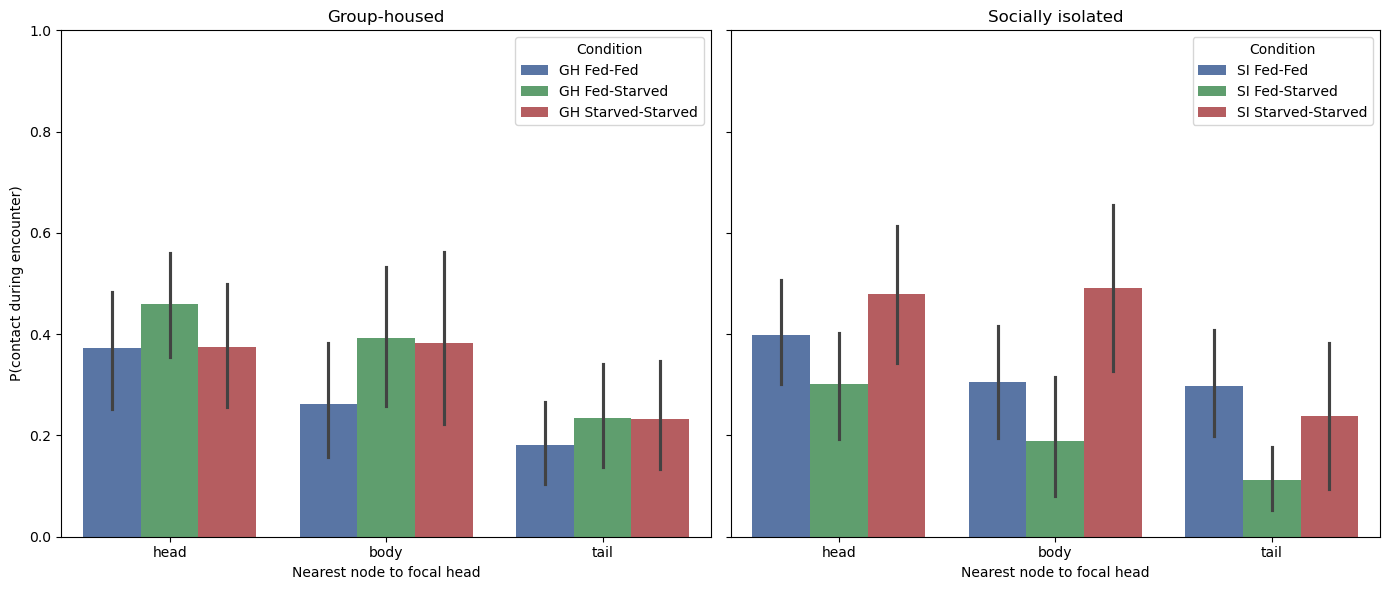

In [18]:
# Probability of future contact by nearest node, grouped by file
prob_by_node = (
    df.groupby(['Condition', 'file', 'nearest_node'], observed=True, as_index=False)
      .agg(
          n_observations=('contact_during_episode', 'size'),
          n_contacts=('contact_during_episode', 'sum')
      )
)
prob_by_node['prob_contact'] = prob_by_node['n_contacts'] / prob_by_node['n_observations']

gh_node = prob_by_node[prob_by_node['Condition'].str.contains('GH')].copy()
si_node = prob_by_node[prob_by_node['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_node,
    x='nearest_node',
    y='prob_contact',
    hue='Condition',
    order=node_order,
    hue_order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Nearest node to focal head')
axes[0].set_ylabel('P(contact during encounter)')
axes[0].set_ylim(0, 1)

# ---------------- SI ----------------
sns.barplot(
    data=si_node,
    x='nearest_node',
    y='prob_contact',
    hue='Condition',
    order=node_order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Nearest node to focal head')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


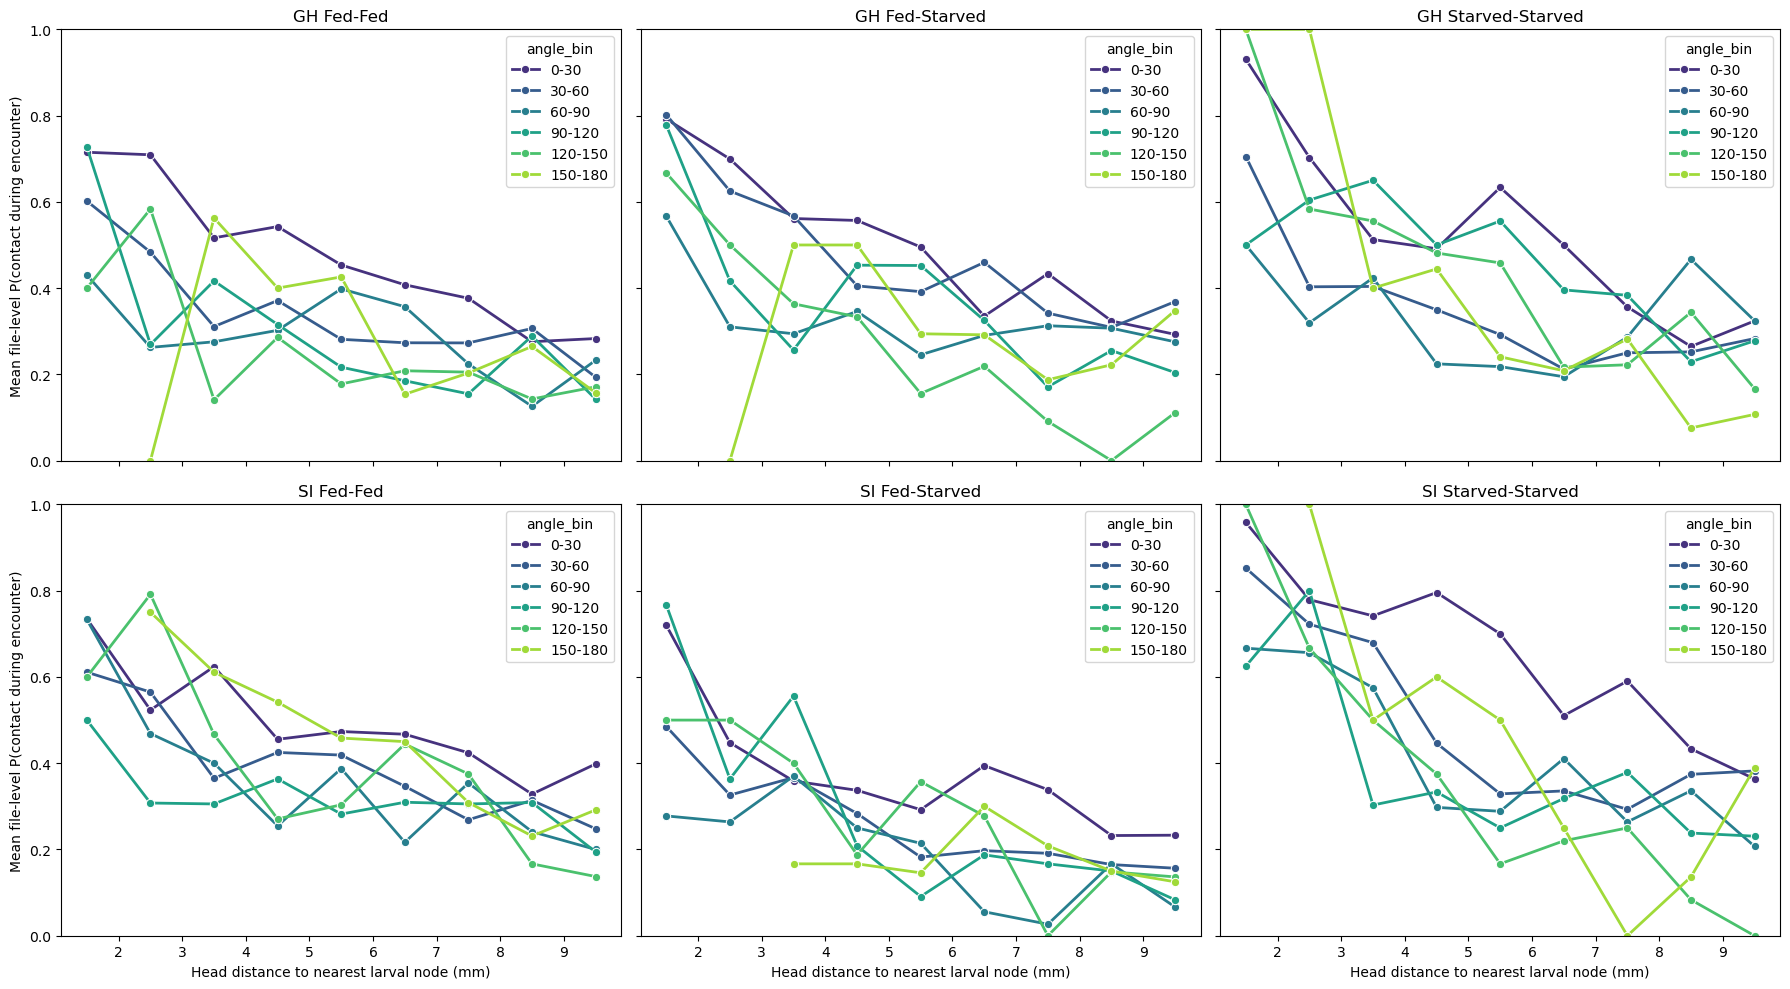

In [19]:
# Probability of future contact by distance and approach angle, grouped by file first
prob_by_distance_angle_file = (
    df.dropna(subset=['distance_center', 'angle_center'])
      .groupby(['Condition', 'file', 'distance_bin', 'distance_center', 'angle_bin', 'angle_center'], observed=True, as_index=False)
      .agg(
          n_observations=('contact_during_episode', 'size'),
          n_contacts=('contact_during_episode', 'sum')
      )
)
prob_by_distance_angle_file['prob_contact'] = (
    prob_by_distance_angle_file['n_contacts'] / prob_by_distance_angle_file['n_observations']
)

prob_by_distance_angle = (
    prob_by_distance_angle_file
      .groupby(['Condition', 'distance_bin', 'distance_center', 'angle_bin', 'angle_center'], observed=True, as_index=False)['prob_contact']
      .mean()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

# ---------------- GH ----------------
for ax, condition in zip(axes[0], gh_order):
    plot_data = prob_by_distance_angle[prob_by_distance_angle['Condition'] == condition].copy()

    sns.lineplot(
        data=plot_data,
        x='distance_center',
        y='prob_contact',
        hue='angle_bin',
        hue_order=angle_order,
        palette='viridis',
        marker='o',
        linewidth=2,
        ax=ax
    )

    ax.set_title(condition)
    ax.set_xlabel('Head distance to nearest larval node (mm)')
    ax.set_ylabel('Mean file-level P(contact during encounter)')
    ax.set_ylim(0, 1)

# ---------------- SI ----------------
for ax, condition in zip(axes[1], si_order):
    plot_data = prob_by_distance_angle[prob_by_distance_angle['Condition'] == condition].copy()

    sns.lineplot(
        data=plot_data,
        x='distance_center',
        y='prob_contact',
        hue='angle_bin',
        hue_order=angle_order,
        palette='viridis',
        marker='o',
        linewidth=2,
        ax=ax
    )

    ax.set_title(condition)
    ax.set_xlabel('Head distance to nearest larval node (mm)')
    ax.set_ylabel('Mean file-level P(contact during encounter)')
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [20]:
# Mean file-level probability table for checking the plotted values
prob_by_condition_distance = (
    prob_by_distance
      .groupby(['Condition', 'distance_bin', 'distance_center'], observed=True, as_index=False)
      .agg(
          mean_prob_contact=('prob_contact', 'mean'),
          sem_prob_contact=('prob_contact', 'sem'),
          n_files=('file', 'nunique')
      )
      .sort_values(['Condition', 'distance_center'])
)

prob_by_condition_distance


,Condition,distance_bin,distance_center,mean_prob_contact,sem_prob_contact,n_files
0,GH Fed-Fed,1-2,1.5,0.577178,0.076226,24
1,GH Fed-Fed,2-3,2.5,0.479064,0.067549,24
2,GH Fed-Fed,3-4,3.5,0.374352,0.065677,25
3,GH Fed-Fed,4-5,4.5,0.381736,0.063227,26
4,GH Fed-Fed,5-6,5.5,0.364720,0.061001,26
5,GH Fed-Fed,6-7,6.5,0.297670,0.060205,26
6,GH Fed-Fed,7-8,7.5,0.317134,0.058427,26
7,GH Fed-Fed,8-9,8.5,0.267735,0.052050,26
8,GH Fed-Fed,9-10,9.5,0.239768,0.053827,26
9,GH Fed-Starved,1-2,1.5,0.732125,0.060960,24
